##Disciplina: 2026.1 - RNA e Deep Learning - CESAR School
**Alunos** :<br>
Gabriel Rocha Franceschini<br>
Breno Mota Ferreira Lima<br>
Vinicius Magalhães de Souza Sena<br>
Renan Victor Cavalcanti Penna

In [3]:
%matplotlib inline
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import os
import torch.nn as nn
import torch.nn.functional as F
import seaborn as sns
from sklearn.metrics import confusion_matrix


In [4]:
#!/bin/bash
!curl -L -o /content/neural-networks-homer-and-bart-classification.zip\
 https://www.kaggle.com/api/v1/datasets/download/juniorbueno/neural-networks-homer-and-bart-classification

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 8248k  100 8248k    0     0  15.4M      0 --:--:-- --:--:-- --:--:-- 15.4M


In [5]:
!unzip neural-networks-homer-and-bart-classification.zip

Archive:  neural-networks-homer-and-bart-classification.zip
replace homer_bart_1/bart1.bmp? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace homer_bart_1/bart10.bmp? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: homer_bart_1/bart10.bmp  
replace homer_bart_1/bart100.bmp? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [6]:
import os
import re

filenames = os.listdir('/content/homer_bart_1')

In [7]:
def extract_name(filename):
  names = []
  for file in filename:
    match = re.match(r"^[a-zA-Z]+", file)
    if match:
      names.append(match.group(0))
    else:
      names.append("Unknown")
  return names

In [8]:
labels = extract_name(filenames)

In [9]:
len(labels)

269

In [10]:
label_dict = {"bart":0,"homer":1}
y = [label_dict.get(label) for label in labels ]
y

[0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,


In [11]:
import torchvision.transforms as transforms
from PIL import Image

path = '/content/homer_bart_1'
img = Image.open(path+'/homer10.bmp')

transform = transforms.ToTensor()

img_tensor = transform(img)

print(img_tensor.shape)

torch.Size([3, 380, 157])


In [12]:
train_size = int(0.8 * len(filenames))
test_size = len(filenames) - train_size

In [13]:
class SimpsonsDataset(Dataset):
    def __init__(self, filenames, labels, img_dir, transform=None):
        self.filenames = filenames
        self.labels = labels
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.filenames[idx])
        image = Image.open(img_path).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

# (64x64 pixels)
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

transformacoes_treino = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

transformacoes_teste = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

dataset_treino = SimpsonsDataset(filenames[:train_size], y[:train_size], '/content/homer_bart_1', transform=transformacoes_treino)
dataset_teste = SimpsonsDataset(filenames[train_size:], y[train_size:], '/content/homer_bart_1', transform=transformacoes_teste)

train_loader = DataLoader(dataset_treino, batch_size=16, shuffle=True)
test_loader = DataLoader(dataset_teste, batch_size=16, shuffle=False)

In [14]:
class MLP_Simpsons(nn.Module):
    def __init__(self):
        super(MLP_Simpsons, self).__init__()
        self.dense = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 64 * 64, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self.dense(x)

model = MLP_Simpsons()

pesos = torch.tensor([1.0, 1.47])
criterion = nn.CrossEntropyLoss(weight=pesos)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

In [15]:
epochs = 50
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(epochs):
    # Training Phase
    model.train()
    running_train_loss = 0.0
    correct_train_predictions = 0
    total_train_predictions = 0

    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total_train_predictions += labels.size(0)
        correct_train_predictions += (predicted == labels).sum().item()

    epoch_train_loss = running_train_loss / len(train_loader)
    epoch_train_accuracy = 100 * correct_train_predictions / total_train_predictions
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_accuracy)

    # Validation Phase
    model.eval()
    running_val_loss = 0.0
    correct_val_predictions = 0
    total_val_predictions = 0

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total_val_predictions += labels.size(0)
            correct_val_predictions += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(test_loader)
    epoch_val_accuracy = 100 * correct_val_predictions / total_val_predictions
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}], " \
          f"Train Loss: {epoch_train_loss:.4f}, " \
          f"Train Acc: {epoch_train_accuracy:.2f}%, " \
          f"Val Loss: {epoch_val_loss:.4f}, " \
          f"Val Acc: {epoch_val_accuracy:.2f}%")

Epoch [1/50], Train Loss: 1.1293, Train Acc: 60.00%, Val Loss: 0.9232, Val Acc: 68.52%
Epoch [2/50], Train Loss: 0.6688, Train Acc: 65.12%, Val Loss: 0.6627, Val Acc: 79.63%
Epoch [3/50], Train Loss: 0.5155, Train Acc: 78.14%, Val Loss: 0.4644, Val Acc: 81.48%
Epoch [4/50], Train Loss: 0.4517, Train Acc: 80.47%, Val Loss: 0.5569, Val Acc: 81.48%
Epoch [5/50], Train Loss: 0.4538, Train Acc: 78.14%, Val Loss: 0.6069, Val Acc: 77.78%
Epoch [6/50], Train Loss: 0.3979, Train Acc: 82.79%, Val Loss: 0.8134, Val Acc: 68.52%
Epoch [7/50], Train Loss: 0.3641, Train Acc: 81.86%, Val Loss: 0.5249, Val Acc: 81.48%
Epoch [8/50], Train Loss: 0.3449, Train Acc: 85.12%, Val Loss: 0.7191, Val Acc: 72.22%
Epoch [9/50], Train Loss: 0.4012, Train Acc: 79.07%, Val Loss: 0.5491, Val Acc: 77.78%
Epoch [10/50], Train Loss: 0.3124, Train Acc: 86.05%, Val Loss: 0.6289, Val Acc: 74.07%
Epoch [11/50], Train Loss: 0.2755, Train Acc: 89.77%, Val Loss: 0.6381, Val Acc: 74.07%
Epoch [12/50], Train Loss: 0.3016, Train 

Acurácia final no Teste: 77.78%


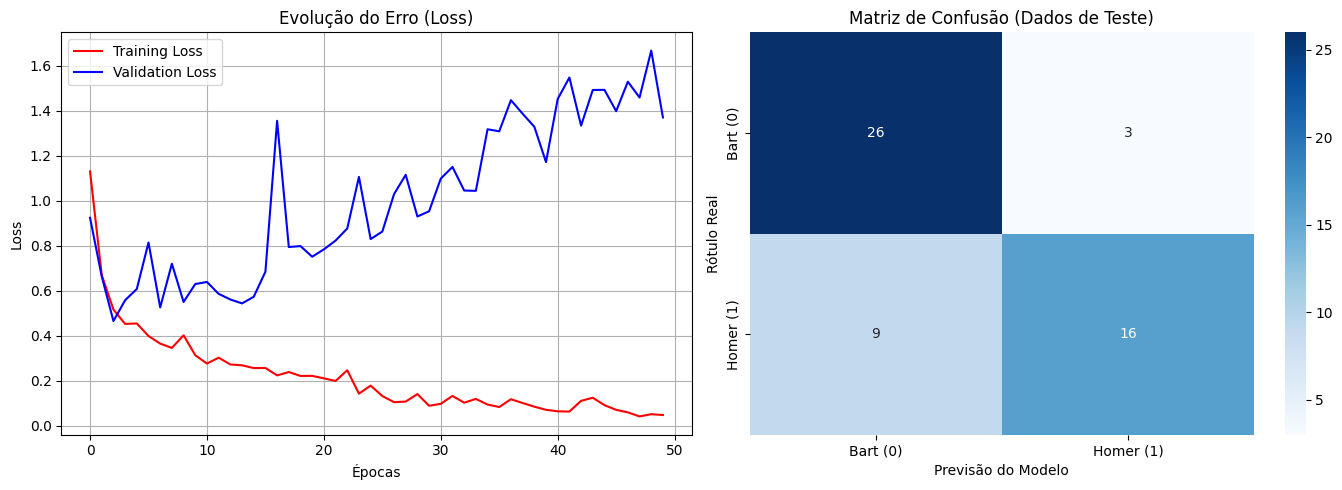

In [16]:
model.eval()
correct = 0
total = 0
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.numpy())

acuracia = 100 * correct / total
print(f"Acurácia final no Teste: {acuracia:.2f}%")


fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plotting Loss
ax[0].plot(train_losses, label='Training Loss', color='red')
ax[0].plot(val_losses, label='Validation Loss', color='blue')
ax[0].set_title('Evolução do Erro (Loss)')
ax[0].set_xlabel('Épocas')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[0].grid(True)

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bart (0)', 'Homer (1)'],
            yticklabels=['Bart (0)', 'Homer (1)'], ax=ax[1])
ax[1].set_title('Matriz de Confusão (Dados de Teste)')
ax[1].set_ylabel('Rótulo Real')
ax[1].set_xlabel('Previsão do Modelo')

plt.tight_layout()
plt.show()

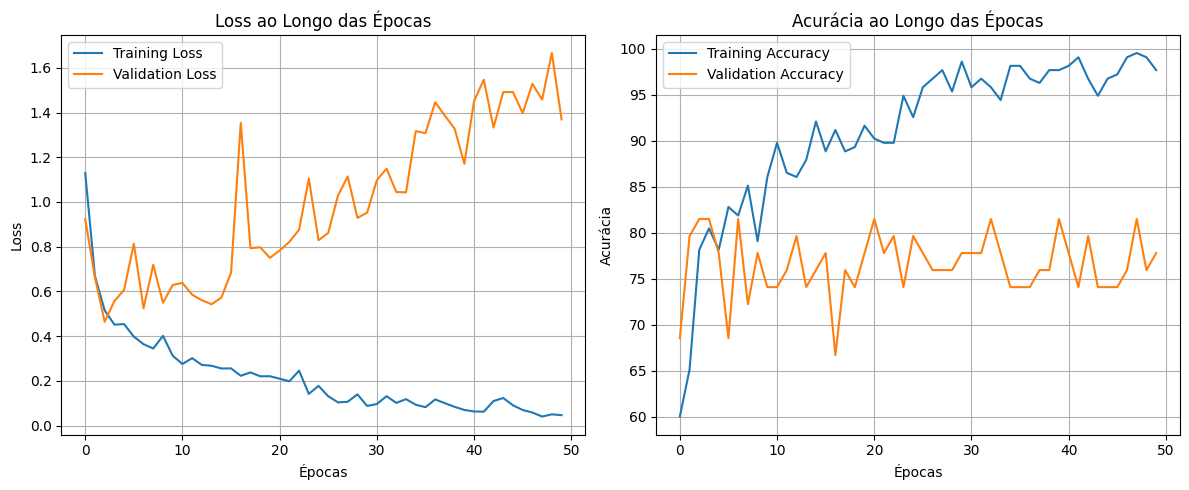

In [17]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Acurácia ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

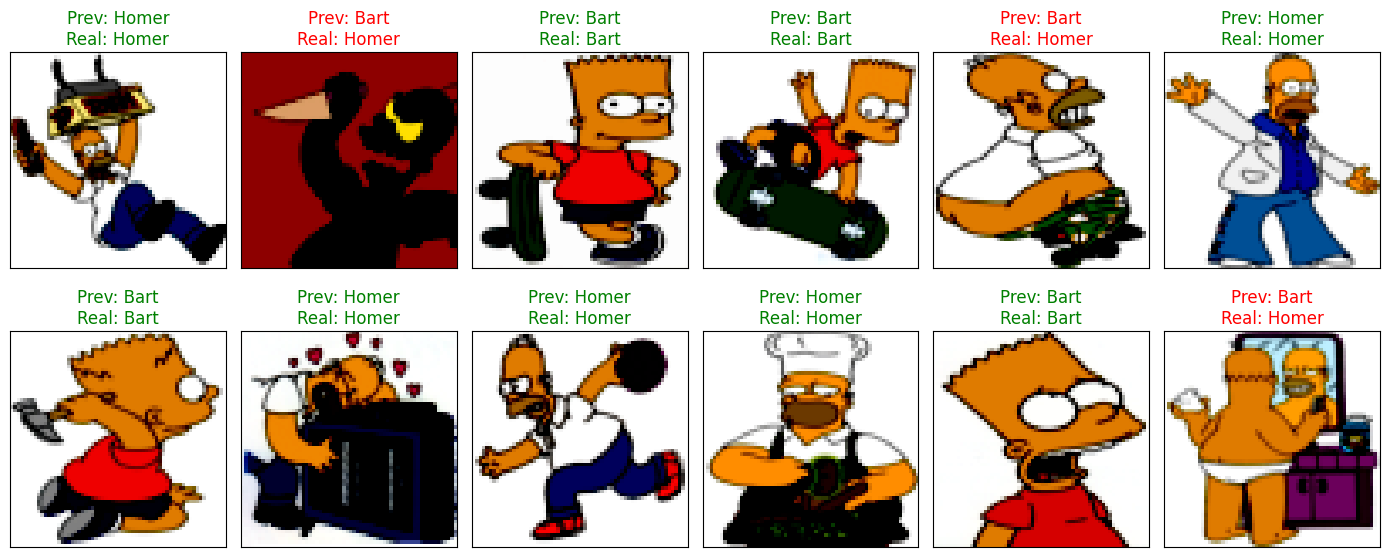

In [18]:
classes = ['Bart', 'Homer']
dataiter = iter(test_loader)
images, labels = next(dataiter)
model.eval()
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

fig = plt.figure(figsize=(14, 6))

for idx in range(12):
    ax = fig.add_subplot(2, 6, idx+1, xticks=[], yticks=[])

    img = images[idx].permute(1, 2, 0).numpy()

    img = np.clip(img, 0, 1)
    ax.imshow(img)

    acertou = predicted[idx] == labels[idx]
    cor = "green" if acertou else "red"

    ax.set_title(f"Prev: {classes[predicted[idx]]}\nReal: {classes[labels[idx]]}", color=cor)

plt.tight_layout()
plt.show()

In [19]:
pd.Series(y).value_counts()

,count
0,160
1,109
